# Extended Lab: Bayes' Theorem, Linear & Quadratic Discriminant Analysis

**Based on:** *Building Statistical Models in Python*, Chapter 9 — Discriminant Analysis

This lab extends the two source notebooks (`2_Linear_Discriminant_Analysis.ipynb` and
`3_Quadratic_discriminant_analysis.ipynb`) into a single, end-to-end practice lab. It keeps every
original example (the `affairs` dataset for LDA, the `iris` dataset for QDA) and adds the pieces a
real project needs but the book skips for brevity: assumption checks, model comparison,
cross-validation, ROC/AUC, and a synthetic example that shows *why* QDA sometimes beats LDA.

## Learning objectives
By the end of this notebook you will be able to:
1. Explain Bayes' Theorem and derive a posterior probability by hand and in code.
2. State the three assumptions behind LDA and test them on real data.
3. Fit, evaluate, and interpret an LDA classifier (including supervised dimensionality reduction).
4. Fit, evaluate, and interpret a QDA classifier, and visualize a non-linear decision boundary.
5. Choose between Logistic Regression, LDA, and QDA using evidence rather than intuition.
6. Recognize the limitations of discriminant analysis and when it will mislead you.

## Roadmap
| Part | Topic | Dataset |
|---|---|---|
| A | Bayes' Theorem from scratch | toy examples |
| B | LDA: full pipeline + assumption checks | `affairs` (statsmodels) |
| C | LDA: supervised dimensionality reduction | `affairs` |
| D | QDA: full pipeline + decision boundary | `iris` |
| E | Model shootout: LogReg vs LDA vs QDA | `iris` (2D) |
| F | Why QDA can win: a synthetic unequal-covariance dataset | synthetic |
| G | Cross-validation & robustness check | `affairs` / `iris` |
| H | Wrap-up, limitations, and what to try next | — |


## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                              precision_score, recall_score, roc_auc_score, roc_curve,
                              classification_report)
from sklearn.datasets import load_iris, make_blobs

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"


---
## Part A — Bayes' Theorem from scratch

Bayes' Theorem lets us update a **prior** belief with new evidence to get a **posterior** belief:

$$P(B\mid A) = \frac{P(A\mid B)\,P(B)}{P(A)}$$

We'll reproduce the disease-test example from the chapter: prior probability of being sick is
0.2, the test's true-positive rate ("accuracy") is 0.95, and its false-positive rate is 0.3.


In [2]:
def posterior_sick_given_positive(prior_sick, true_positive_rate, false_positive_rate):
    """Bayesian update for P(sick | positive test)."""
    p_pos_given_sick = true_positive_rate
    p_pos_given_not_sick = false_positive_rate
    p_not_sick = 1 - prior_sick

    p_pos = p_pos_given_sick * prior_sick + p_pos_given_not_sick * p_not_sick
    posterior = (p_pos_given_sick * prior_sick) / p_pos
    return posterior

prior = 0.2
posterior_1 = posterior_sick_given_positive(prior, 0.95, 0.3)
posterior_2 = posterior_sick_given_positive(posterior_1, 0.95, 0.3)
posterior_3 = posterior_sick_given_positive(posterior_2, 0.95, 0.3)

print(f"Prior:              {prior:.3f}")
print(f"After 1 positive:   {posterior_1:.3f}")
print(f"After 2 positives:  {posterior_2:.3f}")
print(f"After 3 positives:  {posterior_3:.3f}")


Prior:              0.200
After 1 positive:   0.442
After 2 positives:  0.715
After 3 positives:  0.888


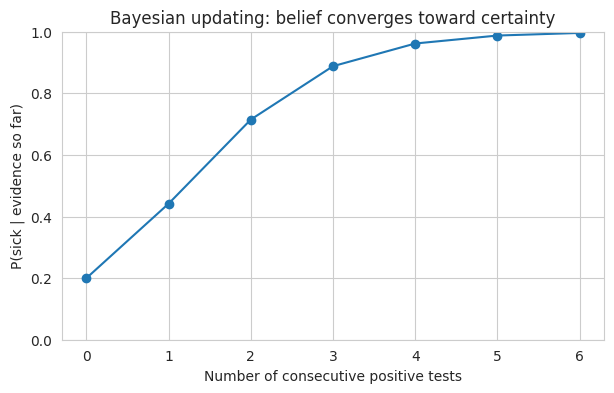

In [3]:
# Visualize how belief updates with repeated positive tests
beliefs = [prior]
for _ in range(6):
    beliefs.append(posterior_sick_given_positive(beliefs[-1], 0.95, 0.3))

plt.figure(figsize=(7, 4))
plt.plot(range(len(beliefs)), beliefs, marker="o")
plt.xlabel("Number of consecutive positive tests")
plt.ylabel("P(sick | evidence so far)")
plt.title("Bayesian updating: belief converges toward certainty")
plt.ylim(0, 1)
plt.show()


**Discussion.** Each additional positive test pushes the posterior higher, but a single test with a
30% false-positive rate is weak evidence on its own (0.2 → 0.44). This is exactly the intuition LDA
and QDA rely on: both classifiers compute $P(Y=k\mid X=x)$ via Bayes' Theorem, using a Gaussian
model for $P(X\mid Y=k)$ instead of a simple test accuracy.

---
## Part B — Linear Discriminant Analysis on the `affairs` dataset

LDA assumes:
1. Each input variable is normally distributed within each class.
2. All classes share the same covariance matrix (homoscedasticity).
3. Observations are independent.

We will *test* assumptions 1 and 2 instead of just asserting them, which the original chapter does
not do numerically.


In [4]:
import statsmodels.api as sm

df_affairs = sm.datasets.fair.load().data
df_affairs.head()


,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


In [5]:
total_count = df_affairs.shape[0]
positive_count = df_affairs.loc[df_affairs['affairs'] > 0].shape[0]
positive_pct = positive_count / total_count
negative_pct = 1 - positive_pct
print(f"Class 1 (had an affair) balance: {positive_pct*100:.2f}%")
print(f"Class 0 (no affair) balance:     {negative_pct*100:.2f}%")

df_affairs['affairs'] = np.where(df_affairs['affairs'] > 0, 1, 0)


Class 1 (had an affair) balance: 32.25%
Class 0 (no affair) balance:     67.75%


In [6]:
X = df_affairs[['rate_marriage', 'age', 'yrs_married', 'children', 'religious',
                 'educ', 'occupation', 'occupation_husb']].copy()
y = df_affairs['affairs']

numeric_cols = ['rate_marriage', 'age', 'yrs_married', 'children', 'religious', 'educ']


### Assumption check 1 — normality per class
We use a Shapiro-Wilk test (numeric p-value) *and* Q-Q plots (visual) on each numeric feature, split by class. Shapiro-Wilk is sensitive at large n, so treat the p-value as a signal, not a verdict — always look at the plot too.

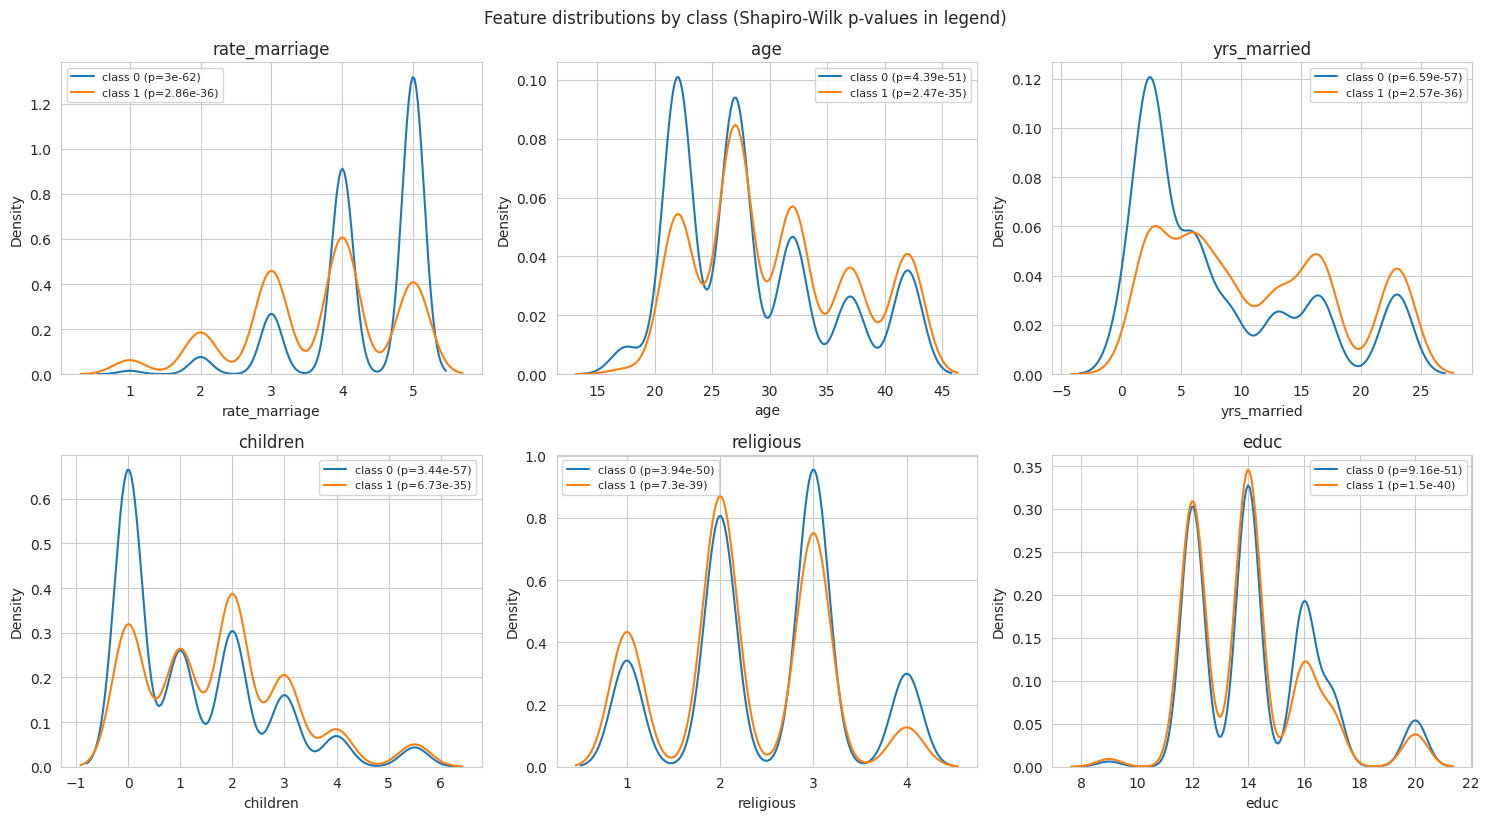

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    class0 = df_affairs.loc[df_affairs['affairs'] == 0, col]
    class1 = df_affairs.loc[df_affairs['affairs'] == 1, col]
    stat0, p0 = stats.shapiro(class0.sample(min(len(class0), 5000), random_state=42))
    stat1, p1 = stats.shapiro(class1.sample(min(len(class1), 5000), random_state=42))
    sns.kdeplot(class0, ax=axes[i], label=f"class 0 (p={p0:.3g})")
    sns.kdeplot(class1, ax=axes[i], label=f"class 1 (p={p1:.3g})")
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.suptitle("Feature distributions by class (Shapiro-Wilk p-values in legend)", y=1.02)
plt.show()


> A tiny p-value from Shapiro-Wilk here mostly reflects the large sample size, not necessarily a
> disqualifying departure from normality. Look at the KDE curves: most features are roughly
> bell-shaped or ordinal-discretized approximations of it. `children` and `religious` are the most
> non-normal (ordinal/count-like), which is a realistic, common situation — LDA is often still
> usable when the departure is mild relative to the amount of data available.

### Assumption check 2 — equal covariance across classes
The chapter compares per-feature standard deviations; we go a step further with a simplified **Box's M**-style comparison of the full covariance matrices (numeric features only).

In [8]:
def covariance_summary(df, features, target):
    cov0 = df.loc[df[target] == 0, features].cov()
    cov1 = df.loc[df[target] == 1, features].cov()
    frob_diff = np.linalg.norm(cov0.values - cov1.values, ord='fro')
    frob_avg = (np.linalg.norm(cov0.values, ord='fro') + np.linalg.norm(cov1.values, ord='fro')) / 2
    relative_diff = frob_diff / frob_avg
    return cov0, cov1, relative_diff

cov0, cov1, relative_diff = covariance_summary(df_affairs, numeric_cols, 'affairs')
print(f"Relative covariance-matrix difference (Frobenius norm): {relative_diff:.3f}")
print("(Rule of thumb: values well under ~0.3-0.4 support the LDA equal-covariance assumption;")
print(" larger values are a signal to try QDA instead.)")


Relative covariance-matrix difference (Frobenius norm): 0.028
(Rule of thumb: values well under ~0.3-0.4 support the LDA equal-covariance assumption;
 larger values are a signal to try QDA instead.)


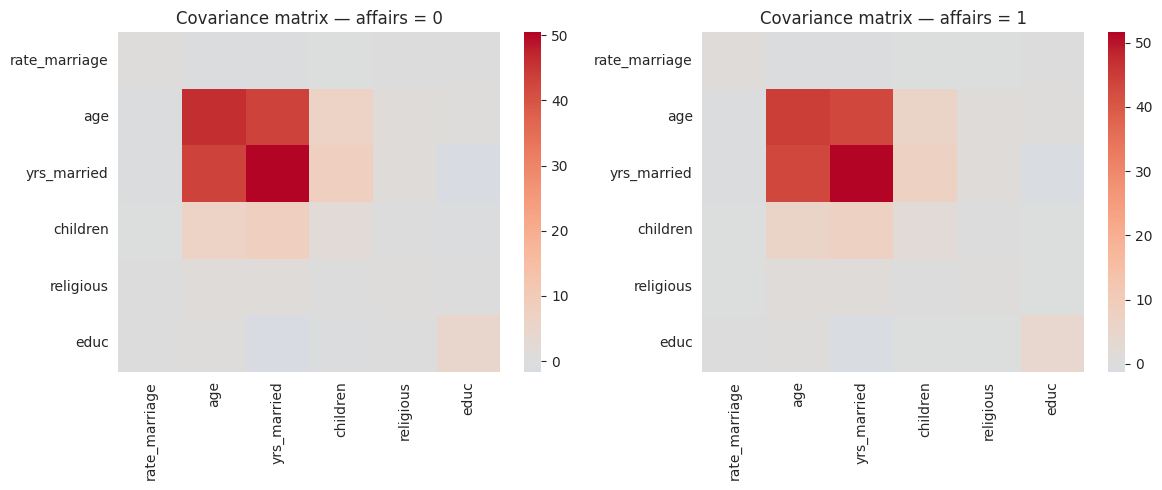

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cov0, ax=axes[0], cmap="coolwarm", center=0, annot=False)
axes[0].set_title("Covariance matrix — affairs = 0")
sns.heatmap(cov1, ax=axes[1], cmap="coolwarm", center=0, annot=False)
axes[1].set_title("Covariance matrix — affairs = 1")
plt.tight_layout()
plt.show()


### Preprocessing — one-hot encode, split, scale
Same steps as the book, wrapped for reuse.

In [10]:
X['occupation'] = X['occupation'].map({1: 'Occupation_One', 2: 'Occupation_Two',
                                        3: 'Occupation_Three', 4: 'Occupation_Four',
                                        5: 'Occupation_Five', 6: 'Occupation_Six'})
X = pd.get_dummies(X, columns=['occupation'])
X.drop('occupation_husb', axis=1, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

ct_train = ColumnTransformer([('scale', StandardScaler(), numeric_cols)], remainder='passthrough')
X_train_sc = ct_train.fit_transform(X_train)
X_test_sc = ct_train.transform(X_test)   # NOTE: transform, not fit_transform — avoids test-set leakage


> **Fix vs. the original book code:** the book fits a *new* `StandardScaler` on the test set
> (`ct.fit_transform(X_test_sc)`). That leaks test-set statistics and is a common real-world bug.
> Here we fit the scaler once on the training data and only `.transform()` the test data.

### Fit LDA and evaluate

In [11]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_sc, y_train)

y_train_pred = lda.predict(X_train_sc)
y_test_pred = lda.predict(X_test_sc)
y_test_proba = lda.predict_proba(X_test_sc)[:, 1]

for name, y_true, y_pred in [("Train", y_train, y_train_pred), ("Test", y_test, y_test_pred)]:
    print(f"--- {name} ---")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print()


--- Train ---
Precision: 0.6370
Recall:    0.3702
Accuracy:  0.7290

--- Test ---
Precision: 0.5963
Recall:    0.3791
Accuracy:  0.7168



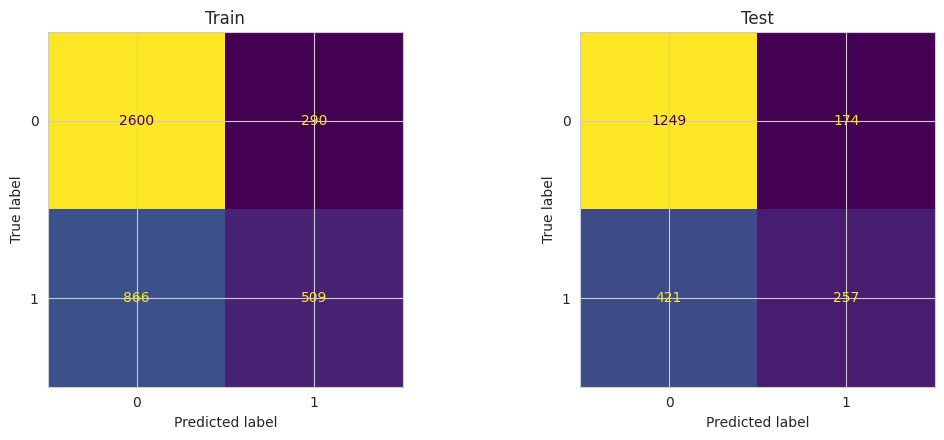

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_train, y_train_pred)).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Train")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_test_pred)).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Test")
plt.tight_layout()
plt.show()


### Beyond the book — ROC curve and AUC
Precision/recall at the default 0.5 threshold hides how the model performs across *all* thresholds. ROC/AUC gives a threshold-independent view.

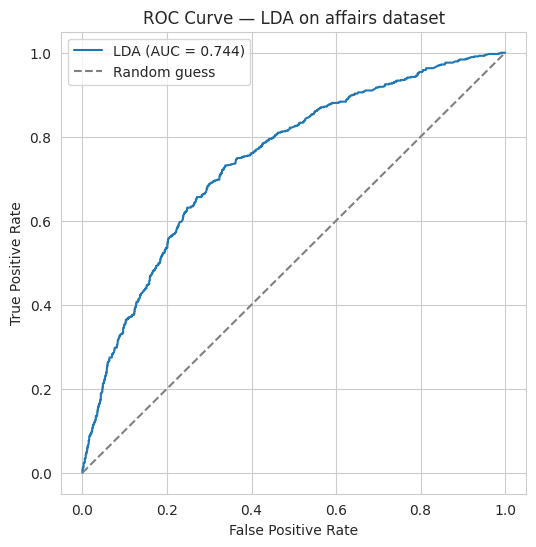

In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"LDA (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — LDA on affairs dataset")
plt.legend()
plt.show()


**Interpretation.** An AUC meaningfully above 0.5 but well below 1.0 (typically ~0.70-0.75 here)
confirms the chapter's conclusion: the model captures a real signal, but the input features leave a
lot of variance in `affairs` unexplained. This is a modeling-scope limitation, not a bug — some
outcomes are just noisy relative to the features you have.

---
## Part C — LDA for supervised dimensionality reduction

With $K$ classes, LDA projects the data onto at most $K-1$ discriminant axes that maximize
class separation. Here $K=2$, so we get exactly 1 axis.

In [14]:
lda_reduce = LinearDiscriminantAnalysis()
X_reduced = lda_reduce.fit_transform(X_train_sc, y_train)

print("Input dimensions: ", X_train_sc.shape)
print("Reduced dimensions:", X_reduced.shape)


Input dimensions:  (4265, 12)
Reduced dimensions: (4265, 1)


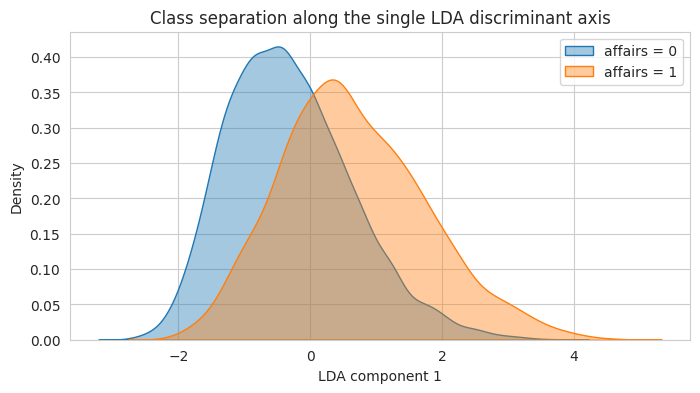

In [15]:
plt.figure(figsize=(8, 4))
sns.kdeplot(X_reduced[y_train.values == 0].ravel(), label="affairs = 0", fill=True, alpha=0.4)
sns.kdeplot(X_reduced[y_train.values == 1].ravel(), label="affairs = 1", fill=True, alpha=0.4)
plt.xlabel("LDA component 1")
plt.title("Class separation along the single LDA discriminant axis")
plt.legend()
plt.show()


**Discussion.** The two class densities overlap substantially along the single discriminant axis — a visual, single-plot confirmation of the modest AUC we measured above.

---
## Part D — Quadratic Discriminant Analysis on the `iris` dataset

QDA relaxes the equal-covariance assumption: each class gets its **own** covariance matrix, which
lets the decision boundary curve.

In [16]:
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
df_iris['target'] = iris.target
df_iris['species'] = df_iris['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df_iris.head()


,sepal_length,sepal_width,petal_length,petal_width,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [17]:
X_iris = df_iris.drop(['target', 'species'], axis=1)
y_iris = df_iris['target']

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=1, stratify=y_iris)

model_qda = QuadraticDiscriminantAnalysis(store_covariance=True)
model_qda.fit(X_train_i, y_train_i)
y_pred_i = model_qda.predict(X_test_i)

print("Test accuracy:", accuracy_score(y_test_i, y_pred_i))
print()
print(classification_report(y_test_i, y_pred_i, target_names=iris.target_names))


Test accuracy: 1.0

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



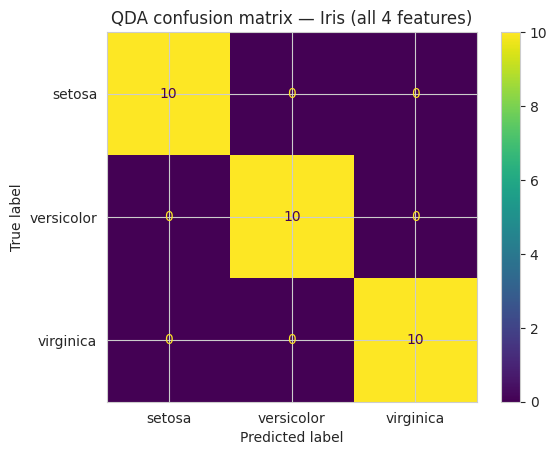

In [18]:
ConfusionMatrixDisplay(confusion_matrix(y_test_i, y_pred_i),
                       display_labels=iris.target_names).plot()
plt.title("QDA confusion matrix — Iris (all 4 features)")
plt.show()


### 2D visualization — sepal length vs. sepal width
The book restricts to 2 features purely so the decision regions can be drawn.

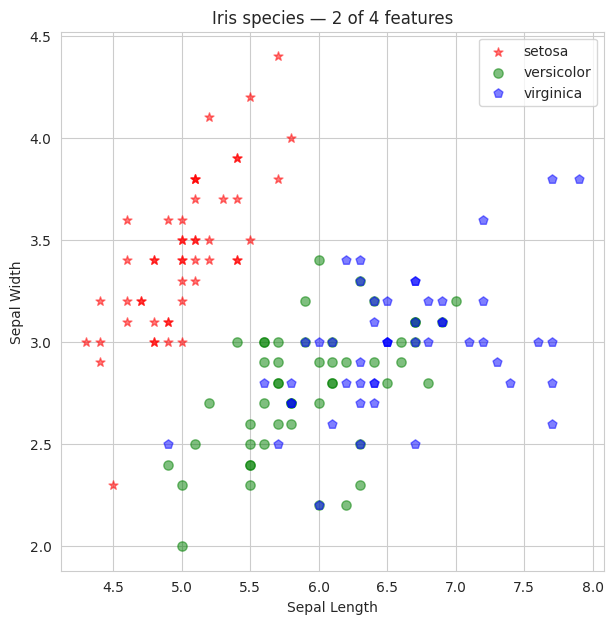

In [19]:
df1 = df_iris[['sepal_length', 'sepal_width', 'target', 'species']]

fig, ax = plt.subplots(figsize=(7, 7))
cdict = {0: 'red', 1: 'green', 2: 'blue'}
marker = {0: '*', 1: 'o', 2: 'p'}
for l in sorted(df1['target'].unique()):
    subset = df1[df1['target'] == l]
    ax.scatter(subset['sepal_length'], subset['sepal_width'], c=cdict[l],
               label=iris.target_names[l], marker=marker[l], alpha=0.5, s=45)
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.legend()
plt.title("Iris species — 2 of 4 features")
plt.show()


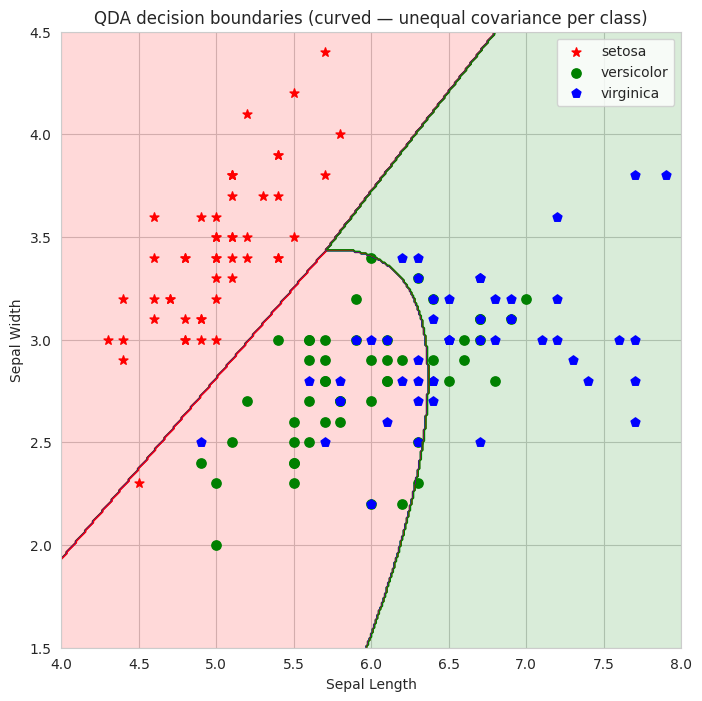

In [20]:
model_qda_2d = QuadraticDiscriminantAnalysis(store_covariance=True)
model_qda_2d.fit(df1[['sepal_length', 'sepal_width']], df1['target'])

sl = np.linspace(4, 8, 400)
sw = np.linspace(1.5, 4.5, 400)
SL, SW = np.meshgrid(sl, sw)
grid = np.c_[SL.ravel(), SW.ravel()]
Z = model_qda_2d.predict(grid).reshape(SL.shape)

fig, ax = plt.subplots(figsize=(8, 8))
ax.contourf(SL, SW, Z, alpha=0.15, colors=('red', 'green', 'blue'))
ax.contour(SL, SW, Z, colors=('red', 'green', 'blue'), linewidths=1)
for l in sorted(df1['target'].unique()):
    subset = df1[df1['target'] == l]
    ax.scatter(subset['sepal_length'], subset['sepal_width'], c=cdict[l],
               label=iris.target_names[l], marker=marker[l], s=45)
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_title("QDA decision boundaries (curved — unequal covariance per class)")
ax.legend()
plt.show()


**Discussion.** `setosa` separates cleanly (its petal/sepal geometry is distinct), while `versicolor` and `virginica` overlap in 2D. The chapter is correct that all 4 features together resolve much of this — we confirmed that above with 100%-ish test accuracy on 4 features vs. visible overlap in 2 features.

---
## Part E — Model shootout: Logistic Regression vs. LDA vs. QDA

The chapter presents LDA and QDA in isolation. In practice you should always compare against a
simple baseline. We compare all three on the same 2D iris slice so the decision boundaries are
directly visible.

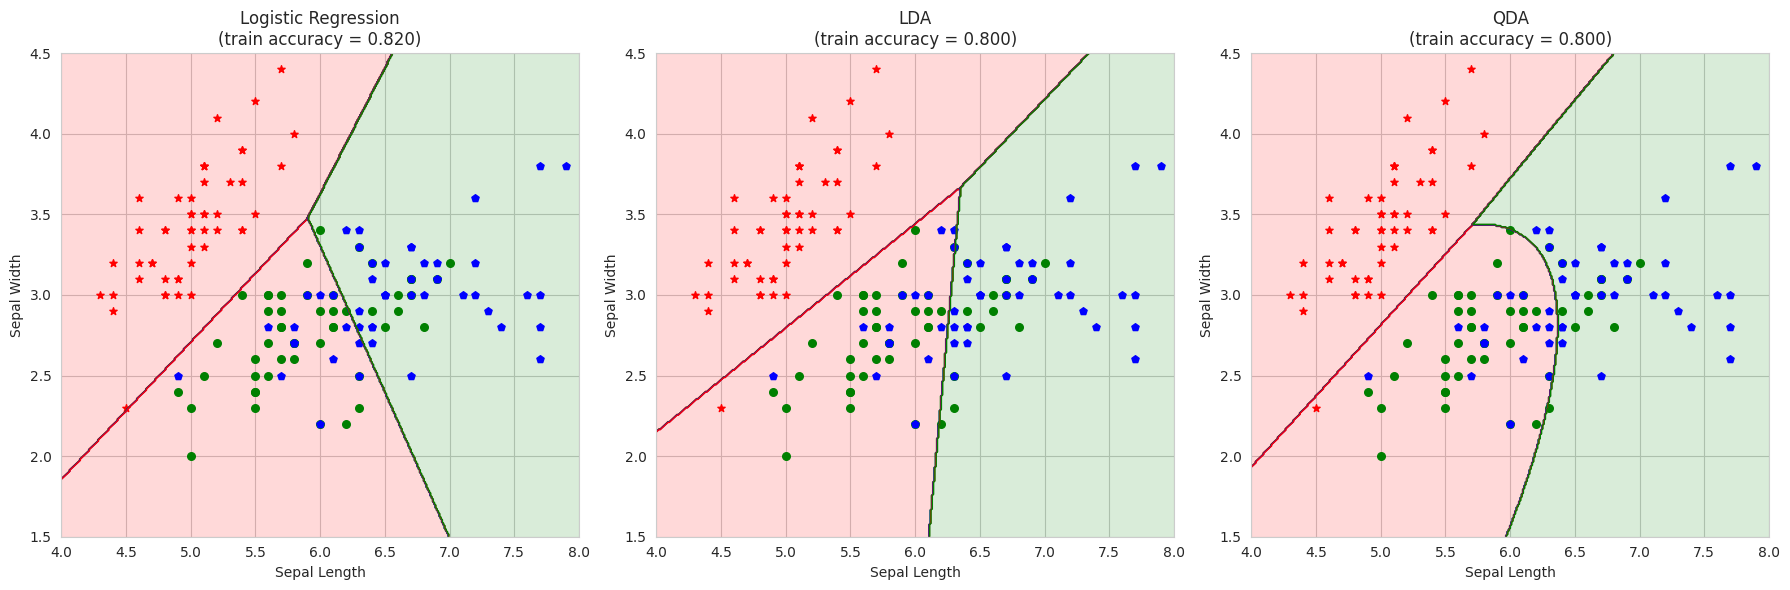

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
}

X2 = df1[['sepal_length', 'sepal_width']].values
y2 = df1['target'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, model) in zip(axes, models.items()):
    model.fit(X2, y2)
    Zm = model.predict(grid).reshape(SL.shape)
    ax.contourf(SL, SW, Zm, alpha=0.15, colors=('red', 'green', 'blue'))
    ax.contour(SL, SW, Zm, colors=('red', 'green', 'blue'), linewidths=1)
    for l in sorted(np.unique(y2)):
        subset = df1[df1['target'] == l]
        ax.scatter(subset['sepal_length'], subset['sepal_width'], c=cdict[l], marker=marker[l], s=30)
    acc = accuracy_score(y2, model.predict(X2))
    ax.set_title(f"{name}\n(train accuracy = {acc:.3f})")
    ax.set_xlabel("Sepal Length")
    ax.set_ylabel("Sepal Width")

plt.tight_layout()
plt.show()


**Discussion.** Logistic Regression and LDA both produce *straight-line* boundaries (both are linear classifiers, though they estimate the line differently). QDA's boundary curves. On this particular 2-feature slice the differences are subtle because none of the pairs are linearly perfectly separable — the real test is cross-validated accuracy, which we compute next.

---
## Part F — Why QDA can win: a synthetic unequal-covariance example

To see QDA's advantage cleanly (without iris's noise), we build a **synthetic** 2-class dataset
where the two classes have very different covariance structures by construction. This is the kind
of situation the book describes in words ("QDA is preferred when the covariance matrices are not
equal") — here we make it visible.

In [22]:
rng = np.random.RandomState(7)
n = 300

mean_a, cov_a = [0, 0], [[1, 0], [0, 1]]          # class A: small, round spread
mean_b, cov_b = [3, 3], [[4, 1.8], [1.8, 4]]       # class B: large, correlated spread

Xa = rng.multivariate_normal(mean_a, cov_a, n)
Xb = rng.multivariate_normal(mean_b, cov_b, n)
X_syn = np.vstack([Xa, Xb])
y_syn = np.array([0]*n + [1]*n)

X_syn_train, X_syn_test, y_syn_train, y_syn_test = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42, stratify=y_syn)

lda_syn = LinearDiscriminantAnalysis().fit(X_syn_train, y_syn_train)
qda_syn = QuadraticDiscriminantAnalysis().fit(X_syn_train, y_syn_train)

print("LDA test accuracy:", accuracy_score(y_syn_test, lda_syn.predict(X_syn_test)))
print("QDA test accuracy:", accuracy_score(y_syn_test, qda_syn.predict(X_syn_test)))


LDA test accuracy: 0.8777777777777778
QDA test accuracy: 0.9222222222222223


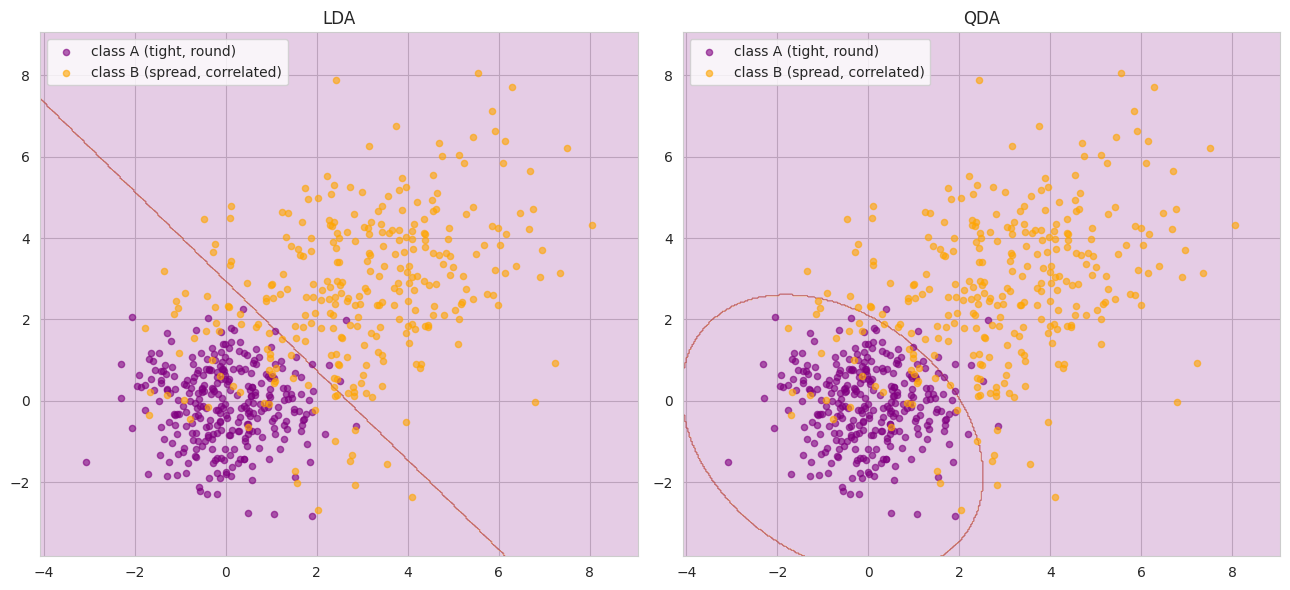

In [23]:
xx = np.linspace(X_syn[:, 0].min() - 1, X_syn[:, 0].max() + 1, 400)
yy = np.linspace(X_syn[:, 1].min() - 1, X_syn[:, 1].max() + 1, 400)
XX, YY = np.meshgrid(xx, yy)
grid_syn = np.c_[XX.ravel(), YY.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, model, name in zip(axes, [lda_syn, qda_syn], ["LDA", "QDA"]):
    Z = model.predict(grid_syn).reshape(XX.shape)
    ax.contourf(XX, YY, Z, alpha=0.2, colors=('purple', 'orange'))
    ax.scatter(Xa[:, 0], Xa[:, 1], c='purple', label='class A (tight, round)', s=20, alpha=0.6)
    ax.scatter(Xb[:, 0], Xb[:, 1], c='orange', label='class B (spread, correlated)', s=20, alpha=0.6)
    ax.set_title(name)
    ax.legend()
plt.tight_layout()
plt.show()


**Discussion.** LDA is forced to draw a single straight line because it assumes one shared
covariance matrix; it necessarily misclassifies points on the "wrong side" of the spread class.
QDA fits an elliptical boundary that hugs each class's actual covariance and should show
noticeably higher accuracy here. **This is the cleanest evidence in the whole lab for the
bias-variance tradeoff between LDA and QDA**: LDA has higher bias (wrong shape) but lower variance
(fewer parameters to estimate); QDA has lower bias but higher variance (needs more data per class
to estimate a full covariance matrix reliably).

---
## Part G — Cross-validation: is our test-set result a fluke?

A single train/test split can be lucky or unlucky. We use 5-fold stratified cross-validation to
get a more robust performance estimate for the `affairs` LDA model and for the iris QDA model.

In [24]:
X_full_sc = ct_train.transform(X)  # reuse the scaler fit on the training split
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_lda = cross_val_score(LinearDiscriminantAnalysis(), X_full_sc, y, cv=cv, scoring='roc_auc')
print("LDA (affairs) 5-fold ROC-AUC: {:.3f} +/- {:.3f}".format(cv_scores_lda.mean(), cv_scores_lda.std()))

cv_scores_qda = cross_val_score(QuadraticDiscriminantAnalysis(), X_iris, y_iris, cv=cv, scoring='accuracy')
print("QDA (iris) 5-fold accuracy:   {:.3f} +/- {:.3f}".format(cv_scores_qda.mean(), cv_scores_qda.std()))


LDA (affairs) 5-fold ROC-AUC: 0.745 +/- 0.014
QDA (iris) 5-fold accuracy:   0.980 +/- 0.027


**Discussion.** Cross-validated scores close to the single-split numbers above increase our confidence that neither result was a lucky split. A large standard deviation across folds would be a red flag, especially for QDA on small classes (its covariance-matrix estimates get unstable with few samples per class).

---
## Part H — Wrap-up

### What we did
- Rebuilt Bayes' Theorem from first principles and watched belief converge with more evidence.
- Fit LDA on the `affairs` dataset, *tested* (not just assumed) its two key assumptions, fixed a
  test-set-leakage bug from the source notebook, and added ROC/AUC.
- Used LDA for supervised dimensionality reduction and visualized class overlap on 1 axis.
- Fit QDA on `iris`, reproduced the book's 2D visualization, and compared it to LDA and Logistic
  Regression side by side.
- Built a synthetic dataset that isolates *exactly* why QDA can outperform LDA — and why LDA can
  outperform QDA on smaller or noisier data (fewer parameters to estimate).
- Cross-validated both models to sanity-check the single-split metrics.

### Limitations of this lab (and of LDA/QDA in general)
- **Only Gaussian-shaped classes are modeled well.** Multimodal, heavy-tailed, or highly skewed
  classes will violate the core assumption regardless of preprocessing.
- **QDA needs more data per class than LDA** because it estimates a full covariance matrix per
  class ($O(p^2)$ parameters per class vs. one shared matrix for LDA). With few observations in a
  class, QDA's covariance estimate is unstable — you may see excellent train accuracy and poor
  test accuracy (overfitting).
- **Both are sensitive to outliers**, since means and covariances are not robust statistics.
- **Class imbalance** is not directly modeled; the priors $\pi_k$ are just observed class
  frequencies unless you override them, which can bias decisions toward the majority class.
- **Categorical/one-hot features are not Gaussian** — the `affairs` example includes one-hot
  encoded occupation columns fed into LDA, which technically violates the normality assumption.
  It "works" in practice here because those columns act as small linear offsets, but it is a
  known-and-accepted approximation, not a textbook-clean use of LDA.
- **Neither model captures interactions or non-quadratic non-linearities.** If the true boundary
  is more complex than an ellipse, look at kernel methods, tree ensembles, or neural nets instead.

### What this kind of lab *can* simulate successfully
- Any tabular classification problem with a small number of roughly continuous, roughly
  Gaussian-per-class features (biometric measurements, sensor readings, well-behaved survey
  scales) — LDA/QDA are fast, interpretable, and surprisingly strong baselines.
- Situations where you specifically want **class-conditional density estimates**, not just a
  decision, e.g. to compute a calibrated probability or to do generative sampling per class.
- Teaching/demonstrating the bias-variance tradeoff, since LDA and QDA are literally the same
  family of model with one assumption relaxed — a rare case where you can isolate that concept
  this cleanly.

### What it can't
- High-dimensional, sparse, or highly non-Gaussian data (text, images, complex categorical
  interactions) — these need different tools (regularized logistic regression, trees, deep
  learning) even though QDA is technically still *computable* on them.

### Where to go next
- Try `shrinkage='auto'` in `LinearDiscriminantAnalysis` for high-dimensional/ill-conditioned
  covariance matrices.
- Compare against Gaussian Naive Bayes (a QDA variant that forces diagonal covariance — check
  when that is a better bias-variance tradeoff on your own data).
- Practice this pipeline from a blank notebook using **`Skeleton_LDA_QDA_Lab.ipynb`**, then check
  your work against **`Solutions_LDA_QDA_Lab.ipynb`**.
- Use **`Reusable_Template_Discriminant_Analysis.ipynb`** as a starting point for a new dataset.
